In [2]:
!pip install tensorflow


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.0 which is incompatible.
streamlit 1.51.0 requires tornado!=6.5.0,<7,>=6.0.3, but you have tornado 6.5 which is incompatible.


  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.78.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cach

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [5]:
iris=load_iris()

In [6]:
data=pd.DataFrame(iris.data,columns=iris.feature_names)
data["labels"]=iris.target

In [7]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),labels
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
x=iris.data
y=iris.target

In [9]:
iris.target_names


array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [10]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [19]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf. keras.layers. Dense (8, activation ='relu'),

    tf.keras.layers.Dense(3, activation ='softmax')
        ])

In [21]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
history=model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=8
)
    

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9417 - loss: 0.1387
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9417 - loss: 0.1354
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9417 - loss: 0.1319
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9333 - loss: 0.1292
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9417 - loss: 0.1258
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9333 - loss: 0.1250
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9417 - loss: 0.1205
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9500 - loss: 0.1187
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9500 - loss: 0.1161 
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9417 - loss: 0.1138
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9333 - loss: 0.1122 
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9333 - 

In [34]:
pred=model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


In [35]:
np.argmax(pred, axis=1)

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 1, 2, 2, 2, 0, 0])

In [36]:
loss, accuracy = model.evaluate(x_train, y_train)
print("accuracy:", accuracy)
print("loss",loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9667 - loss: 0.0707
accuracy: 0.9666666388511658
loss 0.07073213905096054


In [37]:
model.save("C:/Users/archana/Downloads/model1/iris.model1.keras")

In [38]:
history.history.items()

dict_items([('accuracy', [0.9416666626930237, 0.9416666626930237, 0.9416666626930237, 0.9333333373069763, 0.9416666626930237, 0.9333333373069763, 0.9416666626930237, 0.949999988079071, 0.949999988079071, 0.9416666626930237, 0.9333333373069763, 0.9333333373069763, 0.9416666626930237, 0.9666666388511658, 0.9666666388511658, 0.9666666388511658, 0.949999988079071, 0.9583333134651184, 0.9583333134651184, 0.9583333134651184, 0.9666666388511658, 0.9666666388511658, 0.949999988079071, 0.949999988079071, 0.9583333134651184, 0.9666666388511658, 0.9583333134651184, 0.9583333134651184, 0.9583333134651184, 0.9583333134651184, 0.9583333134651184, 0.9583333134651184, 0.9666666388511658, 0.9666666388511658, 0.9583333134651184, 0.9583333134651184, 0.9583333134651184, 0.9666666388511658, 0.9666666388511658, 0.9583333134651184, 0.9583333134651184, 0.9666666388511658, 0.9666666388511658, 0.9666666388511658, 0.9666666388511658, 0.9666666388511658, 0.9666666388511658, 0.9666666388511658, 0.9666666388511658,

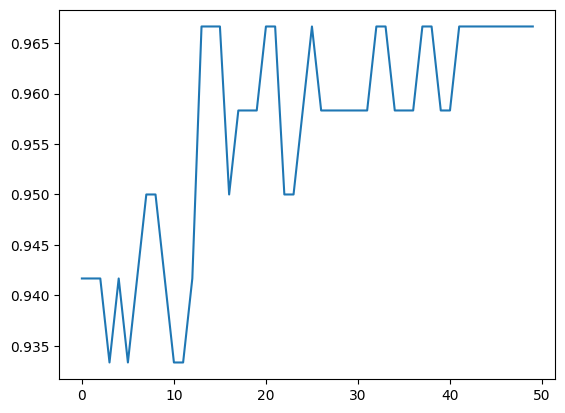

In [39]:
plt.plot(history.history["accuracy"], label="accuracy")